# SOC Alert Anomaly Detection & Scorecard Analysis
### Cyber Fusion Analytics Portfolio Project

This notebook consumes the curated tables produced by `etl/etl_pipeline.py`
and performs the analytical layer a Cyber Fusion / EPO data analyst would
own: identifying anomalous alert volume, flagging analyst SLA risk, and
surfacing the metrics that feed the Power BI-style scorecard.

**Note on data**: all alert data in this project is synthetically
generated (see `data/generate_synthetic_soc_data.py`) for demonstration
purposes. Three volume-spike days were deliberately injected into the
generator so this notebook has a real signal to detect — this is
disclosed here rather than presented as an organic finding.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURATED = "../data/curated"
pd.set_option("display.max_columns", None)

daily_volume = pd.read_csv(f"{CURATED}/daily_volume_by_source.csv", parse_dates=["alert_date"])
alerts = pd.read_csv(f"{CURATED}/alerts_enriched.csv", parse_dates=["alert_timestamp", "alert_date"])
kpi = pd.read_csv(f"{CURATED}/kpi_summary.csv")
analyst_perf = pd.read_csv(f"{CURATED}/analyst_performance.csv")
risk_bu = pd.read_csv(f"{CURATED}/risk_by_business_unit.csv")

print(f"Loaded {len(alerts):,} enriched alerts spanning {alerts['alert_date'].min().date()} to {alerts['alert_date'].max().date()}")
kpi


Loaded 12,324 enriched alerts spanning 2026-04-16 to 2026-07-14


,total_alerts,false_positive_rate_pct,avg_time_to_triage_minutes,sla_breach_rate_pct
0,12324,28.6,834.4,43.5


## 1. Volume Anomaly Detection

Approach: for each `source_system`, compute a rolling 14-day mean and
standard deviation of daily alert volume, then flag any day where volume
exceeds **mean + 3 standard deviations** (a standard control-chart /
"3-sigma" method — simple, explainable to non-technical stakeholders,
and appropriate as a first-pass detector before something like an
Isolation Forest or seasonal-hybrid ESD for production use).


In [2]:
def flag_anomalies(df, value_col="alert_count", window=14, z_thresh=3.0):
    df = df.sort_values("alert_date").copy()
    df["rolling_mean"] = df[value_col].rolling(window, min_periods=5).mean()
    df["rolling_std"] = df[value_col].rolling(window, min_periods=5).std()
    df["z_score"] = (df[value_col] - df["rolling_mean"]) / df["rolling_std"]
    df["is_anomaly"] = df["z_score"] > z_thresh
    return df

anomaly_frames = []
for source, grp in daily_volume.groupby("source_system"):
    anomaly_frames.append(flag_anomalies(grp))
anomaly_df = pd.concat(anomaly_frames).sort_values(["source_system", "alert_date"])

detected = anomaly_df[anomaly_df["is_anomaly"]]
print(f"Flagged {len(detected)} anomalous source/day combinations:")
detected[["alert_date", "source_system", "alert_count", "rolling_mean", "z_score"]]


Flagged 2 anomalous source/day combinations:


,alert_date,source_system,alert_count,rolling_mean,z_score
135,2026-05-08,Firewall,136,27.785714,3.452667
333,2026-06-10,Firewall,146,26.928571,3.452944


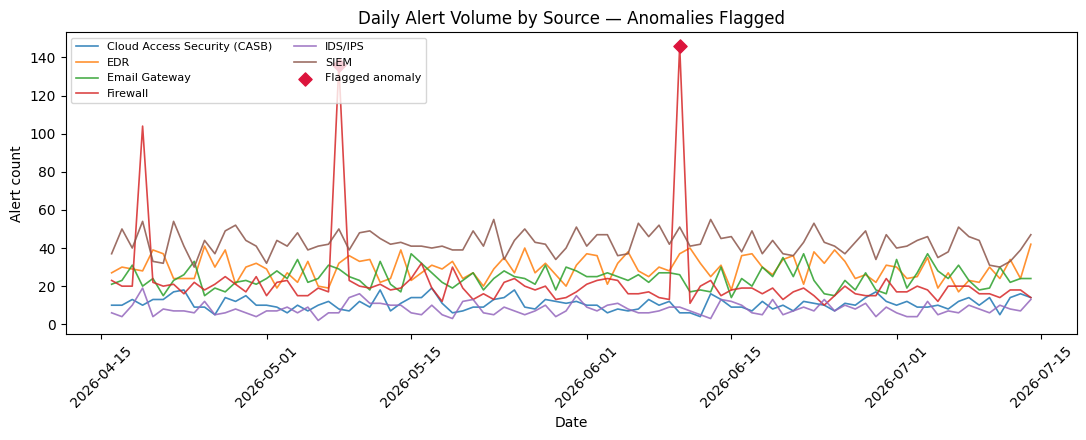

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for source, grp in daily_volume.groupby("source_system"):
    ax.plot(grp["alert_date"], grp["alert_count"], label=source, linewidth=1.2, alpha=0.85)

ax.scatter(detected["alert_date"], detected["alert_count"], color="crimson", zorder=5,
           label="Flagged anomaly", s=45, marker="D")
ax.set_title("Daily Alert Volume by Source — Anomalies Flagged")
ax.set_xlabel("Date")
ax.set_ylabel("Alert count")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/assets_volume_anomaly.png", dpi=140)
plt.show()


## 2. SLA Breach Risk by Analyst

Same triage-time data, viewed operationally: which analysts / shifts are
carrying SLA risk. This is the kind of view a Cyber Fusion lead would use
in a weekly scorecard review to rebalance workload, not to individually
call out analysts — framed here at the shift level as well as analyst
level for that reason.


In [4]:
shift_perf = alerts.groupby("analyst_shift").agg(
    alerts_triaged=("alert_id", "count"),
    avg_triage_minutes=("time_to_triage_minutes", "mean"),
    sla_breach_rate_pct=("sla_breached_calc", lambda s: round(s.mean() * 100, 1)),
).round(1).sort_values("sla_breach_rate_pct", ascending=False)

shift_perf


,alerts_triaged,avg_triage_minutes,sla_breach_rate_pct
analyst_shift,,,
Evening,5299,817.4,44.0
Night,3483,857.6,43.3
Day,3542,837.0,42.8


In [5]:
top_breach_analysts = analyst_perf.sort_values("sla_breach_rate_pct", ascending=False).head(5)
top_breach_analysts


,assigned_analyst,analyst_shift,alerts_triaged,avg_triage_minutes,sla_breach_rate_pct
10,Analyst_01,Evening,868,839.7,46.5
13,Analyst_03,Night,855,856.3,44.4
6,Analyst_08,Evening,875,750.1,44.1
9,Analyst_14,Night,869,864.4,44.0
0,Analyst_07,Evening,907,825.5,44.0


## 3. Severity Mix & False-Positive Rate by Source

False-positive rate by source system is a key tuning signal — a source
with a high FP rate on Medium/Low severity alerts is a candidate for
detection-rule tuning, which is exactly the kind of recommendation this
role is expected to translate into a stakeholder conversation.


In [6]:
fp_by_source = alerts.groupby("source_system").agg(
    total_alerts=("alert_id", "count"),
    false_positive_rate_pct=("false_positive", lambda s: round(s.mean() * 100, 1)),
    avg_triage_minutes=("time_to_triage_minutes", "mean"),
).round(1).sort_values("false_positive_rate_pct", ascending=False)

fp_by_source


,total_alerts,false_positive_rate_pct,avg_triage_minutes
source_system,,,
EDR,2624,29.2,853.3
Firewall,1995,29.2,866.3
SIEM,3842,28.7,815.3
Cloud Access Security (CASB),965,28.1,851.5
Email Gateway,2181,27.9,819.4
IDS/IPS,717,27.6,801.4


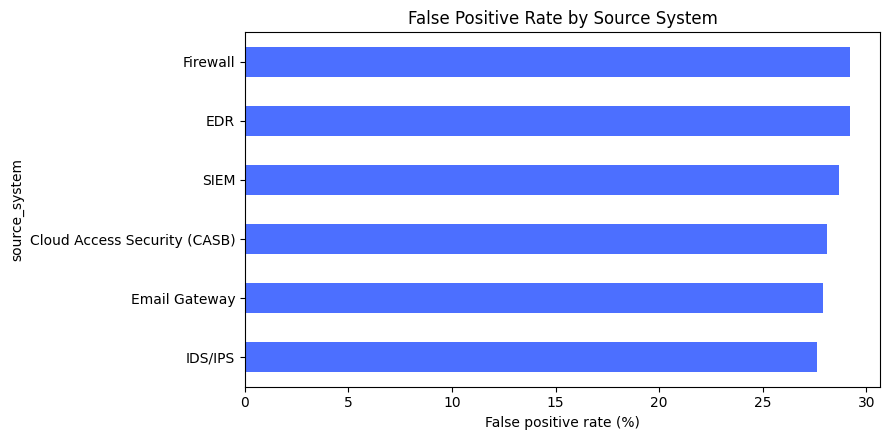

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
fp_by_source["false_positive_rate_pct"].sort_values().plot(kind="barh", ax=ax, color="#4C6FFF")
ax.set_xlabel("False positive rate (%)")
ax.set_title("False Positive Rate by Source System")
plt.tight_layout()
plt.savefig("../dashboard/assets_fp_rate_by_source.png", dpi=140)
plt.show()


## 4. Summary — Findings for the Scorecard

These bullets are the kind of "translate analytical findings into clear
recommendations" output called for in the JD, written for a
non-technical stakeholder audience.


In [8]:
print("KPI SUMMARY")
print(kpi.to_string(index=False))
print()
print(f"Anomalous volume days detected: {len(detected)}")
print(f"Highest-FP-rate source: {fp_by_source['false_positive_rate_pct'].idxmax()} "
      f"({fp_by_source['false_positive_rate_pct'].max()}% FP rate)")
print(f"Shift with highest SLA breach rate: {shift_perf['sla_breach_rate_pct'].idxmax()} "
      f"({shift_perf['sla_breach_rate_pct'].max()}%)")


KPI SUMMARY
 total_alerts  false_positive_rate_pct  avg_time_to_triage_minutes  sla_breach_rate_pct
        12324                     28.6                       834.4                 43.5

Anomalous volume days detected: 2
Highest-FP-rate source: EDR (29.2% FP rate)
Shift with highest SLA breach rate: Evening (44.0%)
